In [1]:
import jax
import jax.numpy as jnp
from jax import random, grad, vmap
from jax.tree import map
from functools import partial
import optax
from flax.training import train_state
from flax import linen as nn
from jax.scipy.integrate import trapezoid

In [2]:
# Define a simple MLP using Flax Linen
class MLP(nn.Module):
    architecture: list
    hidden_activation: callable = nn.tanh

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.architecture) - 1):
            x = nn.Dense(features=self.architecture[i + 1])(x)
            if i < len(self.architecture) - 2:
                x = self.hidden_activation(x)
        return x

In [158]:
def local_energy_batch(params, xs, model_apply):
    # get ψ(x) for the whole batch
    psi = jax.vmap(lambda x: model_apply(params, x))(xs)

    # first and second derivative wrt x for the whole batch
    dpsi_dx = jnp.gradient(psi, xs.squeeze(), axis=0)
    d2psi_dx2 = jnp.gradient(dpsi_dx, xs.squeeze(), axis=0)

    kinetic = -0.5 * d2psi_dx2 / psi
    potential = (0.5 * xs**2).reshape(-1,1)
    return kinetic + potential

def log_psi(x, params, model_apply):
    psi = model_apply(params, x)
    return jnp.log(jnp.abs(psi) + 1e-8).squeeze()  # Add small constant to avoid log(0)

grad_log_psi = jax.grad(lambda params, x, model_apply: log_psi(x, params, model_apply), argnums=0) # CAREFUL WITH THE DERIVATIVES: WE WANT THE GRADIENT WRT THE PARAMETERS, so we turn the order of the p and x

# now grad_log_psi is a function that takes (params, x, model_apply) and returns the gradient of log_psi wrt params

def energy_fn(params, batch, model_apply):
    psi = jax.vmap(lambda x: model_apply(params, x))(batch)
    psi_squared = jnp.abs(psi)**2
    local_energy_per_point = local_energy_batch(params, batch, model_apply)

    E = jnp.mean(local_energy_per_point)
    return E

def loss_and_grads(params, batch, model_apply):
    local_energy_per_point = local_energy_batch(params, batch, model_apply)
    E = energy_fn(params, batch, model_apply)
    E_centered = local_energy_per_point - E
    log_psi_grads = jax.vmap(lambda x: grad_log_psi(params, x, model_apply))(batch)
    grad_E = jax.tree_util.tree_map(lambda g: 2 *jnp.mean(E_centered[:, None] * g), log_psi_grads)
    return E, grad_E

@jax.jit
def train_step(state, batch):
    E, grads = loss_and_grads(state.params, batch, state.apply_fn)
    new_state = state.apply_gradients(grads=grads)
    return new_state, E

@partial(jax.jit, static_argnums=(1,))
def mh_kernel(rng_key, prob_fn, prob_params, position, prob, PBC=None):
    key1, key2 = random.split(rng_key)
    proposal = position + random.normal(key1, shape=position.shape)
    # ensure PBC
    proposal = jax.lax.cond(
    PBC is None,
    lambda p: p,
    lambda p: ((p + 0.5 * PBC) % PBC) - 0.5 * PBC,
    proposal
    )
    proposal_prob = prob_fn(proposal, prob_params)
    accept = jax.random.uniform(key2) < (proposal_prob / prob)
    new_position = jnp.where(accept, proposal, position)
    new_prob = jnp.where(accept, proposal_prob, prob)
    return new_position, new_prob


@partial(jax.jit, static_argnums=(1, 2, 3))
def mh_chain(rng_key, n_steps, PBC, prob_fn, prob_params, init_position):
    def body_fn(i, val):
        key, position, prob = val
        _, key = random.split(key)
        new_position, new_prob = mh_kernel(
            key, prob_fn, prob_params, position, prob, PBC=PBC
        )
        return key, new_position, new_prob

    init_prob = prob_fn(init_position, prob_params)
    init_val = (rng_key, init_position, init_prob)
    _, positions, _ = jax.lax.fori_loop(0, n_steps, body_fn, init_val)
    return positions

def nan_callback(x):
    if jnp.isnan(x).any():
        return True
    return False

def train(n_steps, init_params, model_apply, optimizer, PBC=10):

    state = train_state.TrainState.create(
        apply_fn=model_apply,
        params=init_params,
        tx=optimizer
    )

    def prob_fn(x, params):
        # Ensure x has a batch dimension, run the MLP, and return non-negative per-input values.
        x = jnp.atleast_1d(x).reshape(-1, 1)  # (batch, 1)
        forward = model_apply(params, x).flatten()  # (batch,)
        out = jnp.square(forward)  # non-negative density probability
        return jnp.squeeze(out)  # scalar for scalar input, (batch,) for batch

    energy_history = []
    # batch = jnp.linspace(-5,5,1000).reshape(-1,1)
    sampler = jax.vmap(mh_chain, in_axes=(0, None,None,  None, None, 0), out_axes=0)
    n_chains = 1_000
    rng_keys = random.split(random.PRNGKey(42), n_chains)
    init_position = jnp.zeros(n_chains)*jax.random.normal(random.PRNGKey(0), (n_chains,))
    wf_hist = []
    n_steps_sampler = 150
    best_energy = jnp.inf
    best_params = None

    import numpy as np
    import json

    for step in range(n_steps):
        rng_keys = random.split(random.PRNGKey(step), n_chains)
        batch = sampler(rng_keys, n_steps_sampler, PBC, prob_fn, state.params, init_position)
        batch = batch.reshape(-1,1)  # Flatten the chains into a single batch
        state, energy = train_step(state, batch)
        energy_history.append(energy)
        wf_hist.append(state.params)
        if energy < best_energy:
            best_energy = energy
            best_params = state.params
        if nan_callback(energy):
            print("NaN detected in energy, stopping training.")
            break


        if step % 100 == 0:
            print(f"Step {step}, Energy: {energy}")
            # print("Current parameters:")
            # print(state.params)
            print("==============================")

    return state.params, energy_history, wf_hist, best_params, best_energy

Step 0, Energy: 20.037033081054688
Step 100, Energy: 9.435990333557129
Step 200, Energy: 8.522602081298828
Step 300, Energy: 8.29029655456543
Step 400, Energy: 8.339488983154297
Step 500, Energy: 6.215576648712158
Step 600, Energy: 6.525130271911621
Step 700, Energy: 4.646149635314941
NaN detected in energy, stopping training.


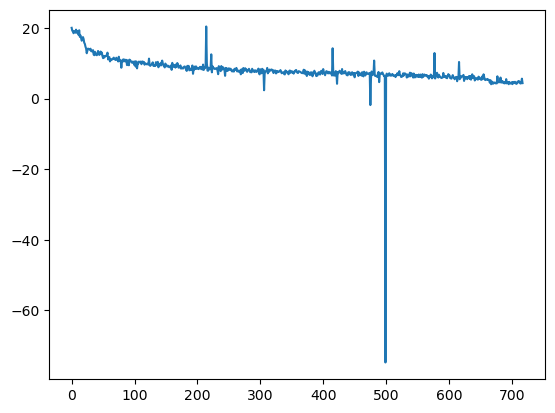

<class 'jaxlib._jax.ArrayImpl'>
(1000, 1)
Norm: nan
Norm after normalization: nan


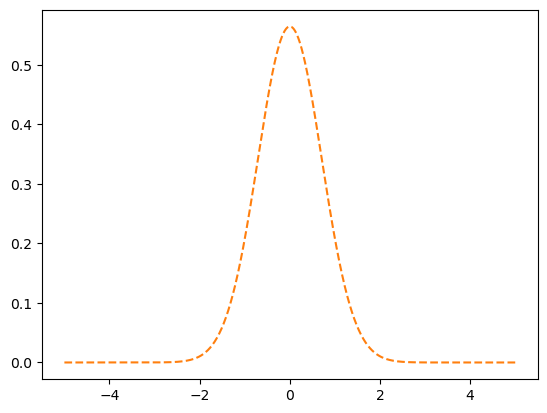

In [159]:
model = MLP(architecture=[1, 15, 1])
rng = jax.random.PRNGKey(0)
input_shape = (10_000, 1)  # Batch size of 1000, input dimension
params = model.init(rng, jnp.ones(input_shape)*0.01)  # Initialize parameters
params_fin, energy, wf_hist, best_params, best_energy = train(50_000, params, model.apply, optax.adam(1e-2), PBC=20.0)
import matplotlib.pyplot as plt
plt.plot(energy)
plt.show()

# Reconstruct wavefunction
x = jnp.linspace(-5,5,1000).reshape(-1,1)
psi_approx = model.apply(params_fin, x)
print(type(psi_approx))
print(psi_approx.shape)
norm = jnp.sqrt(trapezoid((psi_approx**2).squeeze(), x.squeeze()))
print(f"Norm: {norm}")
psi_approx = psi_approx / norm
print(f"Norm after normalization: {jnp.sqrt(trapezoid((psi_approx**2).squeeze(), x.squeeze()))}")
plt.plot(x, psi_approx**2)
plt.plot(x, jnp.pi**(-0.5)*jnp.exp(-x**2), linestyle='dashed')

In [152]:
def generate_gif(wf_hist, x, filename="wavefunction_evolution.gif"):
    import matplotlib.pyplot as plt
    import matplotlib.animation as animation

    fig, ax = plt.subplots()
    line, = ax.plot(x, jnp.zeros_like(x))
    ax.set_ylim(0, 1.5 * jnp.max(jnp.pi**(-0.5)*jnp.exp(-x**2)))
    ax.set_title("Wavefunction Evolution")
    ax.set_xlabel("x")
    ax.set_ylabel(r"$|\psi(x)|^2$")

    def update(frame):
        params = wf_hist[frame*100]
        psi = model.apply(params, x)
        norm = jnp.sqrt(trapezoid((psi**2).squeeze(), x.squeeze()))
        psi = psi / norm
        line.set_ydata(psi**2)
        ax.set_title(f"Wavefunction Evolution - Step {frame*100}")
        return line,

    ani = animation.FuncAnimation(fig, update, frames=len(wf_hist)//100, blit=True)
    # ani.save(filename, writer='imagemagick', fps=5)
    ani.save(filename, writer='pillow', fps=5)
    plt.close()


x = jnp.linspace(-10,10,1000).reshape(-1,1)
generate_gif(wf_hist, x)

Best energy: -74.77108001708984


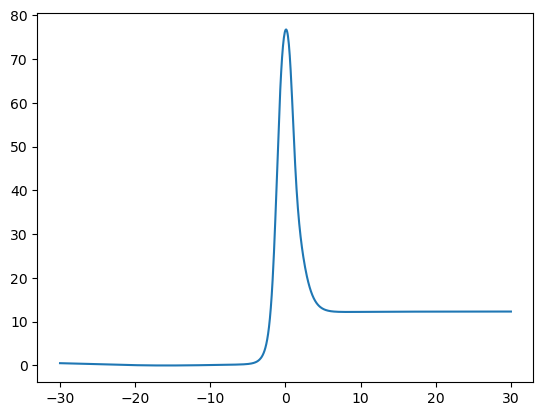

In [153]:
print(f"Best energy: {best_energy}")
x = jnp.linspace(-30, 30,1000).reshape(-1,1)
plt.plot(x, model.apply(best_params, x)**2)

Text(0.5, 1.0, 'Wavefunction at step 11378 with energy 18.543678283691406')

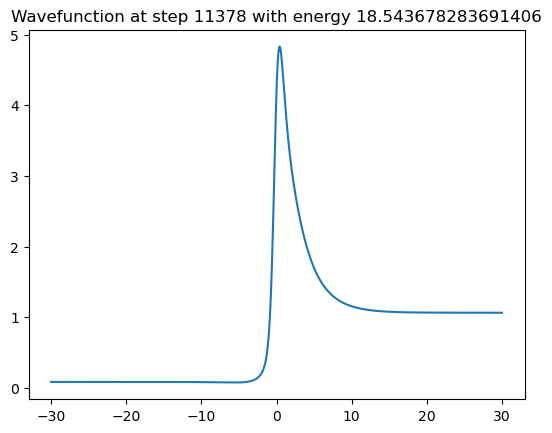

In [144]:
idx = 11_378
energy_current = energy[idx]
params = wf_hist[idx]
plt.plot(x, model.apply(params, x)**2)
plt.title(f"Wavefunction at step {idx} with energy {energy_current}")